In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Ruta base del proyecto.
PROJECT_DIR = Path.cwd()

# Carpetas de datos crudos
DRUGS_AT_FDA_DIR = PROJECT_DIR / "drugsatfda"
ORANGE_BOOK_DIR = PROJECT_DIR / "orange_book"

# Carpetas de salida que usaremos 
DATA_INTERMEDIATE_DIR = PROJECT_DIR / "data_intermediate"
DATA_FINAL_DIR = PROJECT_DIR / "data_final"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"

print("\nArchivos en Drugs@FDA:")
if DRUGS_AT_FDA_DIR.exists():
    for file in sorted(DRUGS_AT_FDA_DIR.iterdir()):
        print(" -", file.name)

print("\nArchivos en Orange Book:")
if ORANGE_BOOK_DIR.exists():
    for file in sorted(ORANGE_BOOK_DIR.iterdir()):
        print(" -", file.name)


Archivos en Drugs@FDA:
 - ActionTypes_Lookup.txt
 - ApplicationDocs.txt
 - Applications.txt
 - ApplicationsDocsType_Lookup.txt
 - Join_Submission_ActionTypes_Lookup.txt
 - MarketingStatus.txt
 - MarketingStatus_Lookup.txt
 - Products.txt
 - SubmissionClass_Lookup.txt
 - SubmissionPropertyType.txt
 - Submissions.txt
 - TE.txt

Archivos en Orange Book:
 - exclusivity.txt
 - patent.txt
 - products.txt


In [3]:
# Lectura inicial de las tablas principales
def read_text_table(path, sep, encoding="latin1"):
   
    return pd.read_csv(
        path,
        sep=sep,
        dtype=str,
        encoding=encoding,
        low_memory=False
    )

# Drugs@FDA
fda_applications = read_text_table(DRUGS_AT_FDA_DIR / "Applications.txt", sep="\t")
fda_products = read_text_table(DRUGS_AT_FDA_DIR / "Products.txt", sep="\t")
fda_submissions = read_text_table(DRUGS_AT_FDA_DIR / "Submissions.txt", sep="\t")
fda_marketing = read_text_table(DRUGS_AT_FDA_DIR / "MarketingStatus.txt", sep="\t")
fda_te = read_text_table(DRUGS_AT_FDA_DIR / "TE.txt", sep="\t")

# Orange Book
ob_products = read_text_table(ORANGE_BOOK_DIR / "products.txt", sep="~")
ob_patent = read_text_table(ORANGE_BOOK_DIR / "patent.txt", sep="~")
ob_exclusivity = read_text_table(ORANGE_BOOK_DIR / "exclusivity.txt", sep="~")

# Resumen de estructura
tables = {
    "ob_products": ob_products,
    "ob_patent": ob_patent,
    "ob_exclusivity": ob_exclusivity,
    "fda_applications": fda_applications,
    "fda_products": fda_products,
    "fda_submissions": fda_submissions,
    "fda_marketing": fda_marketing,
    "fda_te": fda_te,
}

for name, df in tables.items():
    print("=" * 80)
    print(name)
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}")
    print("Columnas:")
    print(list(df.columns))
    print()

ob_products
Filas: 48,083 | Columnas: 14
Columnas:
['Ingredient', 'DF;Route', 'Trade_Name', 'Applicant', 'Strength', 'Appl_Type', 'Appl_No', 'Product_No', 'TE_Code', 'Approval_Date', 'RLD', 'RS', 'Type', 'Applicant_Full_Name']

ob_patent
Filas: 20,858 | Columnas: 10
Columnas:
['Appl_Type', 'Appl_No', 'Product_No', 'Patent_No', 'Patent_Expire_Date_Text', 'Drug_Substance_Flag', 'Drug_Product_Flag', 'Patent_Use_Code', 'Delist_Flag', 'Submission_Date']

ob_exclusivity
Filas: 2,054 | Columnas: 5
Columnas:
['Appl_Type', 'Appl_No', 'Product_No', 'Exclusivity_Code', 'Exclusivity_Date']

fda_applications
Filas: 29,036 | Columnas: 4
Columnas:
['ApplNo', 'ApplType', 'ApplPublicNotes', 'SponsorName']

fda_products
Filas: 51,144 | Columnas: 8
Columnas:
['ApplNo', 'ProductNo', 'Form', 'Strength', 'ReferenceDrug', 'DrugName', 'ActiveIngredient', 'ReferenceStandard']

fda_submissions
Filas: 191,818 | Columnas: 8
Columnas:
['ApplNo', 'SubmissionClassCodeID', 'SubmissionType', 'SubmissionNo', 'Submissio

In [4]:
#Lo que yo pude ver aqui es como el identificador o nuetsra llave primaria tiene diferencias en la tipografía
#Supongo que mas adelante lo checaremos; a su vez logro ver que estan relacionados 29,036 aplicaciones a 191,818 filas de submissions
#Por lo que puedo suponer que por cada aplicación tendremos mucho papeleo

In [5]:
#La siguiente celda muestra las primeras filas de cada tabla principal. Esta revisión es exploratoria y ayudará a decidir cómo normalizar fechas, llaves y nombres de columnas.

In [6]:
for name, df in tables.items():
    print("=" * 100)
    print(name)
    print("=" * 100)
    print(df.head(5))
    print("\n")

ob_products
                  Ingredient               DF;Route              Trade_Name             Applicant       Strength  \
0                 BUDESONIDE   AEROSOL, FOAM;RECTAL              BUDESONIDE        PADAGIS ISRAEL  2MG/ACTUATION   
1                 BUDESONIDE   AEROSOL, FOAM;RECTAL                  UCERIS                 SALIX  2MG/ACTUATION   
2  MINOCYCLINE HYDROCHLORIDE  AEROSOL, FOAM;TOPICAL                  AMZEEQ               JOURNEY     EQ 4% BASE   
3               AZELAIC ACID  AEROSOL, FOAM;TOPICAL            AZELAIC ACID  AUROBINDO PHARMA USA            15%   
4     BETAMETHASONE VALERATE  AEROSOL, FOAM;TOPICAL  BETAMETHASONE VALERATE               ALEMBIC          0.12%   

  Appl_Type Appl_No Product_No TE_Code Approval_Date  RLD   RS   Type                 Applicant_Full_Name  
0         A  215328        001      AB  Apr 12, 2023   No  Yes     RX  PADAGIS ISRAEL PHARMACEUTICALS LTD  
1         N  205613        001      AB   Oct 7, 2014  Yes   No     RX      

### Resumen de Exploración de Datos

La revisión inicial de los datos crudos confirma que la lectura fue exitosa.
Por un lado, las tablas del Orange Book (**ob_products**, **ob_patent** y **ob_exclusivity**) contienen las variables explicativas sobre barreras de entrada y protección comercial, siendo **ob_products** clave para distinguir entre medicamentos originales (NDA) y genéricos (ANDA) e identificar el código de equivalencia "AB". Por otro lado, de las cinco tablas de Drugs@FDA, **fda_submissions** es la más crítica, ya que al registrar el historial de todos los trámites nos permitirá extraer la fecha exacta de la primera aprobación original, la cual marcará el tiempo $t=0$ para el modelo; el resto de las tablas regulatorias servirán para unificar nombres y características físicas. Como diagnóstico para la fase de limpieza, antes de poder cruzar, se deben resolver dos inconsistencias detectadas: las llaves primarias tienen nombres y formatos distintos (`Appl_No` frente a `ApplNo`) y las columnas de tiempo manejan formatos diferentes. El siguiente bloque de código se encargará de normalizar los títulos, rellenar las llaves numéricas con ceros a la izquierda para homogeneizarlas y estandarizar las fechas.

In [7]:
import re #patrones de texto

def clean_column_name(col):
    """Convierte nombres de columnas a formato snake_case sencillo."""
    col = col.strip() #quita espacios al inicio y final
    col = col.replace(";", "_") #cambia punto y coma por guion bajo
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col) # Cambia esos simb por guion bajo
    col = re.sub(r"_+", "_", col) #si hay varios guiones bajos, deja solo uno
    col = col.strip("_") #quita guiones bajos en los extremos
    return col.lower() #todo a minúsculas

def standardize_columns(df):
    """Estandariza nombres de columnas."""
    out = df.copy() #copia para no dañar la orginial
    out.columns = [clean_column_name(c) for c in out.columns] #limpia cada título
    return out #devuelve la tabla con títulos limpios

def normalize_appl_no(x):
    """Normaliza número de aplicación FDA a texto de 6 dígitos."""
    if pd.isna(x): #si la celda está vacía
        return np.nan # la deja como nulo
    x = str(x).strip() #convierte a texto y quita espacios
    x = re.sub(r"\.0$", "", x) #borra ".0" si aparece al final
    x = re.sub(r"\D", "", x) #todo lo que no sea número
    if x == "": #si quedó vacía tras limpiar
        return np.nan #devuelve nulo
    return x.zfill(6) #rellena con ceros a la izquierda hasta 6 dígitos

def normalize_product_no(x):
    """Normaliza número de producto FDA a texto de 3 dígitos."""
    if pd.isna(x): #lo mismo
        return np.nan
    x = str(x).strip() 
    x = re.sub(r"\.0$", "", x) 
    x = re.sub(r"\D", "", x) 
    if x == "": 
        return np.nan 
    return x.zfill(3) #rellena con ceros hasta tener 3 dígitos

# Crear copias limpias de las tablas
ob_products_clean = standardize_columns(ob_products) # Limpia títulos de ob_products
ob_patent_clean = standardize_columns(ob_patent) # Limpia títulos de ob_patent
ob_exclusivity_clean = standardize_columns(ob_exclusivity) 
fda_applications_clean = standardize_columns(fda_applications) 
fda_products_clean = standardize_columns(fda_products) 
fda_submissions_clean = standardize_columns(fda_submissions) 
fda_marketing_clean = standardize_columns(fda_marketing) 
fda_te_clean = standardize_columns(fda_te) 

# Normalizar llaves en Orange Book
for df in [ob_products_clean, ob_patent_clean, ob_exclusivity_clean]: #recorre las 3 tablas
    if "appl_no" in df.columns: # Si existe la columna appl_no...
        df["appl_no"] = df["appl_no"].apply(normalize_appl_no) #aplica regla de 6 dígitos
    if "product_no" in df.columns: # Si existe product_no...
        df["product_no"] = df["product_no"].apply(normalize_product_no) #aplica regla de 3 dígitos

# Normalizar llaves en Drugs@FDA
for df in [fda_applications_clean, fda_products_clean, fda_submissions_clean, fda_marketing_clean, fda_te_clean]: #Recorre las 5 tablas
    if "applno" in df.columns: # Si se llama 'applno'...
        df.rename(columns={"applno": "appl_no"}, inplace=True) #renombra a 'appl_no' para que ya quede igual 
    if "productno" in df.columns: # Si se llama 'productno'...
        df.rename(columns={"productno": "product_no"}, inplace=True) #renombra a 'product_no'
        
    if "appl_no" in df.columns: #ya renombrada, si existe appl_no
        df["appl_no"] = df["appl_no"].apply(normalize_appl_no) #aplica regla de 6 dígitos
    if "product_no" in df.columns: #si existe product_no
        df["product_no"] = df["product_no"].apply(normalize_product_no) #aplica regla de 3 dígitos

# Guardar tablas limpias en un diccionario para revisión
clean_tables = { # Crea un agrupador para las tablas ya limpias 
    "ob_products_clean": ob_products_clean, #guarda la tabla limpia
    "ob_patent_clean": ob_patent_clean, #guarda la tabla limpia
    "ob_exclusivity_clean": ob_exclusivity_clean, 
    "fda_applications_clean": fda_applications_clean, 
    "fda_products_clean": fda_products_clean, 
    "fda_submissions_clean": fda_submissions_clean, 
    "fda_marketing_clean": fda_marketing_clean, 
    "fda_te_clean": fda_te_clean, 
}

# Resumen de columnas normalizadas y ejemplos de llaves
for name, df in clean_tables.items(): #recorre tabla por tabla
    print("=" * 100) 
    print(name) #nombre de la tabla
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}") #conteo de filas y columnas
    print("Columnas:") 
    print(list(df.columns)) # Muestra títulos finales
    
    key_cols = [c for c in ["appl_no", "product_no"] if c in df.columns] #busca si existen llaves aquí
    if key_cols: #si encontró llaves
        print("\nEjemplos de llaves:") #imprime texto
        print(df[key_cols].head(10).to_string(index=False)) #muestra los primeros 10 datos limpios
    print() 

ob_products_clean
Filas: 48,083 | Columnas: 14
Columnas:
['ingredient', 'df_route', 'trade_name', 'applicant', 'strength', 'appl_type', 'appl_no', 'product_no', 'te_code', 'approval_date', 'rld', 'rs', 'type', 'applicant_full_name']

Ejemplos de llaves:
appl_no product_no
 215328        001
 205613        001
 212379        001
 210928        001
 215832        001
 207144        001
 078337        001
 208204        001
 210639        001
 214688        001

ob_patent_clean
Filas: 20,858 | Columnas: 10
Columnas:
['appl_type', 'appl_no', 'product_no', 'patent_no', 'patent_expire_date_text', 'drug_substance_flag', 'drug_product_flag', 'patent_use_code', 'delist_flag', 'submission_date']

Ejemplos de llaves:
appl_no product_no
 020610        001
 018613        001
 019734        002
 019734        005
 020832        007
 020845        002
 020845        003
 020845        003
 021038        002
 021038        003

ob_exclusivity_clean
Filas: 2,054 | Columnas: 5
Columnas:
['appl_type', 'a

### Lo que podemos ver 
La tabla ob_products_clean conserva 48,083 productos; fda_products_clean conserva 51,144 productos; y fda_submissions_clean contiene 191,818 registros regulatorios. Esta última será clave para identificar fechas de aprobación asociadas a envíos originales y aprobados.

Con las llaves ya estandarizadas, el siguiente paso será revisar la calidad de esas llaves: cuántos valores faltantes existen, cuántas aplicaciones únicas hay en cada tabla y qué tan grande es la intersección entre Orange Book y Drugs@FDA.

### Revisión de calidad de llaves e intersección entre fuentes

Después de normalizar las columnas y las llaves, conviene revisar la calidad de los identificadores principales.

En la siguiente celda se calculará, para cada tabla:
* Número total de filas.
* Número de aplicaciones únicas (`appl_no`).
* Número de productos únicos por combinación (`appl_no`, `product_no`), cuando aplique.
* Número de valores faltantes en `appl_no`.
* Número de valores faltantes en `product_no`, cuando aplique.

También se calcularán algunas intersecciones entre fuentes. Esto permitirá saber cuántas aplicaciones aparecen tanto en el Orange Book como en Drugs@FDA.


In [8]:
def key_quality_summary(name, df): #define función para auditar las llaves de la tabla
    """Resume la calidad de llaves principales en una tabla.""" 
    out = { #un diccionario para guardar resultados
        "table": name, #guarda el nombre de la tabla
        "rows": len(df), #cuenta el total de filas
        "columns": df.shape[1], #columnas
        "missing_appl_no": df["appl_no"].isna().sum() if "appl_no" in df.columns else np.nan, #cuenta vacíos en appl_no (o da nulo si no existe)
        "unique_appl_no": df["appl_no"].nunique(dropna=True) if "appl_no" in df.columns else np.nan, #cuenta aplicaciones únicas sin repetir
        "missing_product_no": df["product_no"].isna().sum() if "product_no" in df.columns else np.nan, #cuenta vacíos en product_no
        "unique_appl_product": ( #conteo combinado
            df[["appl_no", "product_no"]].dropna().drop_duplicates().shape[0] #Cuenta pares únicos de aplicación-producto
            if {"appl_no", "product_no"}.issubset(df.columns) #solo lo hace si existen ambas columnas
            else np.nan #si falta alguna, da nulo
        ), 
    } 
    return out #devuelve el resumen estadístico

key_summary = pd.DataFrame([ #convierte en un DF
    key_quality_summary(name, df) # 
    for name, df in clean_tables.items()]) #lo hace para cada tabla en tu diccionario
print(key_summary)

# Intersecciones entre fuentes
ob_appls = set(ob_products_clean["appl_no"].dropna().unique()) #crea conjunto matemático de aplicaciones únicas del Orange Book
fda_appls = set(fda_applications_clean["appl_no"].dropna().unique()) # =========de FDA Applications
fda_prod_appls = set(fda_products_clean["appl_no"].dropna().unique())
fda_sub_appls = set(fda_submissions_clean["appl_no"].dropna().unique())

print("=" * 80) 
print("Intersecciones de aplicaciones") 
print("=" * 80)
print(f"Aplicaciones únicas en Orange Book products: {len(ob_appls):,}") #total del conjunto Orange Book
print(f"Aplicaciones únicas en Drugs@FDA Applications: {len(fda_appls):,}") #total del conjunto FDA Applications
print(f"Aplicaciones únicas en Drugs@FDA Products: {len(fda_prod_appls):,}") #FDA Products
print(f"Aplicaciones únicas en Drugs@FDA Submissions: {len(fda_sub_appls):,}") #FDA Submissions

print("\nIntersección OB products ∩ FDA Applications:") 
print(f"{len(ob_appls & fda_appls):,}") #cruce (el símbolo & significa intersección matemática)

print("\nIntersección OB products ∩ FDA Products:") 
print(f"{len(ob_appls & fda_prod_appls):,}") # Imprime cuántos coinciden en ambas bases

print("\nIntersección OB products ∩ FDA Submissions:") 
print(f"{len(ob_appls & fda_sub_appls):,}") # Imprime cuántos coinciden en ambas bases

print("\nAplicaciones en Orange Book products que no aparecen en FDA Applications:") 
print(f"{len(ob_appls - fda_appls):,}") # Muestra diferencia 

print("\nAplicaciones en FDA Applications que no aparecen en Orange Book products:") 
print(f"{len(fda_appls - ob_appls):,}") # Muestra diferencia pero al reves 

                    table    rows  columns  missing_appl_no  unique_appl_no  missing_product_no  unique_appl_product
0       ob_products_clean   48083       14                0           27067                 0.0              48083.0
1         ob_patent_clean   20858       10                0            1309                 0.0               2588.0
2    ob_exclusivity_clean    2054        5                0             552                 0.0               1035.0
3  fda_applications_clean   29036        4                0           29036                 NaN                  NaN
4      fda_products_clean   51144        8                0           28690                 0.0              51144.0
5   fda_submissions_clean  191818        8                0           27771                 NaN                  NaN
6     fda_marketing_clean   51757        3                0           29020                 0.0              51757.0
7            fda_te_clean   26081        4                0     

### como resultado tenemos 
En las tablas principales podemos observar que las llaves primarias como appl_no y product_no estan completas , esto nos da paso a vincular informacion entre los productos, patentes,exclusividades, equivalencia terpeutica y aprobacion.

La tabla ob_products_clean contiene 48,083 productos correspondientes a 27,067 aplicaciones únicas. Por su parte, fda_applications_clean contiene 29,036 aplicaciones únicas, y fda_products_clean contiene 51,144 productos correspondientes a 28,690 aplicaciones únicas.

La intersección entre Orange Book y Drugs@FDA es muy alta:

27,064 aplicaciones aparecen tanto en ob_products_clean como en fda_applications_clean.
27,066 aplicaciones aparecen tanto en ob_products_clean como en fda_products_clean.
Esto significa que casi todas las aplicaciones registradas en Orange Book pueden vincularse con Drugs@FDA usando appl_no.

También se observa que la intersección entre ob_products_clean y fda_submissions_clean es menor: 24,479 aplicaciones. Esto es razonable, ya que la tabla de envíos regulatorios puede no contener información completa para todas las aplicaciones históricas o puede depender de la disponibilidad de registros de aprobación en Drugs@FDA.

Un resultado importante es que solo 3 aplicaciones aparecen en Orange Book pero no en fda_applications_clean. En cambio, 1,972 aplicaciones aparecen en Drugs@FDA pero no en Orange Book. Esto también es esperable, porque Drugs@FDA puede incluir aplicaciones históricas, productos no listados actualmente en Orange Book u otros registros regulatorios.

* En conjunto, estos resultados indican que la llave appl_no es suficientemente sólida para continuar. El siguiente paso será explorar los tipos de aplicación y separar productos innovadores (NDA) de productos genéricos (ANDA), usando tanto Orange Book como Drugs@FDA.

## NDA & ANDA
Ahora nos fijaremos en la variable appl_type que nos arroja valores como ANDA NDA BLA , donde NDA son las patentes o inovadores y ANDA son los genéricos 

La siguiente celda revisa:

distribución de appl_type en Orange Book;
distribución de appltype en Drugs@FDA;
número de productos y aplicaciones por tipo;
algunos ejemplos de productos NDA y ANDA.

Esta exploración permitirá comenzar a definir la cohorte preliminar de medicamentos innovadores y los posibles genéricos asociados.

In [9]:
print("=" * 80) 
print("Distribución de appl_type en Orange Book products") 
print("=" * 80) 
print( 
    ob_products_clean["appl_type"] #toma la columna que indica si es original o genérico
    .value_counts(dropna=False) #cuenta cuántas veces aparece cada tipo, incluyendo nulos
    .rename_axis("appl_type") #le pone nombre al índice para que se vea limpio
    .reset_index(name="n_products") # Lo convierte en DataFrame y nombra la columna de conteo
) 

print("\n" + "=" * 80) 
print("Aplicaciones únicas por appl_type en Orange Book products") 
print("=" * 80) 
print( 
    ob_products_clean #toma la tabla de productos del Orange Book
    .groupby("appl_type", dropna=False) #agrupa los datos por tipo de aplicación
    .agg( 
        n_products=("appl_no", "size"), #cuenta el total de filas (productos) por tipo
        n_applications=("appl_no", "nunique"), #cuenta medicamentos únicos sin repetir
        n_ingredients=("ingredient", "nunique"), #ingredientes activos únicos
        n_trade_names=("trade_name", "nunique") #nombres comerciales únicos
    ) 
    .reset_index() #convierte el resultado agrupado en una tabla normal
    .sort_values("n_products", ascending=False) #ordena de mayor a menor cantidad de productos
)

print("\n" + "=" * 80) 
print("Distribución de appltype en Drugs@FDA Applications") 
print("=" * 80) 
print(
    fda_applications_clean["appltype"] #toma la columna de tipo de aplicación en base FDA
    .value_counts(dropna=False) #cuenta cuántos registros hay por tipo
    .rename_axis("appltype") 
    .reset_index(name="n_applications") 
) 

print("\n" + "=" * 80) 
print("Ejemplos de productos Orange Book tipo N") 
print("=" * 80) 
print(
    ob_products_clean.loc[ # Usa .loc para filtrar filas y seleccionar columnas específicas
        ob_products_clean["appl_type"].eq("N"), # Condición: que el tipo de aplicación sea 'N' (NDA)
        ["appl_no", "product_no", "ingredient", "trade_name", "df_route", "strength", "te_code", "approval_date", "rld", "rs", "type"] #colum que deseo ver 
    ].head(10)
) 

print("\n" + "=" * 80)
print("Ejemplos de productos Orange Book tipo A") # genéricos
print("=" * 80) 
print(
    ob_products_clean.loc[
        ob_products_clean["appl_type"].eq("A"), # Condición: que el tipo de aplicación sea 'A' (ANDA)
        ["appl_no", "product_no", "ingredient", "trade_name", "df_route", "strength", "te_code", "approval_date", "rld", "rs", "type"] # Lista de las mismas columnas clave
    ].head(10) 
) 

Distribución de appl_type en Orange Book products
  appl_type  n_products
0         A       37291
1         N       10792

Aplicaciones únicas por appl_type en Orange Book products
  appl_type  n_products  n_applications  n_ingredients  n_trade_names
0         A       37291           21576           1469           2894
1         N       10792            5491           2645           5021

Distribución de appltype en Drugs@FDA Applications
  appltype  n_applications
0     ANDA           22724
1      NDA            5843
2      BLA             469

Ejemplos de productos Orange Book tipo N
   appl_no product_no                                 ingredient trade_name               df_route  \
1   205613        001                                 BUDESONIDE     UCERIS   AEROSOL, FOAM;RECTAL   
2   212379        001                  MINOCYCLINE HYDROCHLORIDE     AMZEEQ  AEROSOL, FOAM;TOPICAL   
22  205175        001                          ECONAZOLE NITRATE      ECOZA  AEROSOL, FOAM;TOPICAL   

In [10]:
#BLA (Biológicos): Son para medicamentos de moléculas ultra complejas. No se pueden sintetizar químicamente;
#se tienen que cultivar o extraer de organismos vivos, como células, bacterias o levaduras
#(ej. Vacunas, insulina, toxina botulínica, sangre, terapias génicas o anticuerpos).

## Distribución de Aplicaciones y Limpieza de Fechas


En el Orange Book, la variable appl_type toma dos valores principales:
* **A:** Productos asociados a ANDA, usualmente genéricos.
* **N:** Productos asociados a NDA, usualmente innovadores o productos de referencia.

La distribución observada fue:
* 37,291 productos tipo A.
* 10,792 productos tipo N.

En términos de aplicaciones únicas, el Orange Book contiene:
* 21,576 aplicaciones ANDA.
* 5,491 aplicaciones NDA.
* Esto muestra que la mayor parte del Orange Book corresponde a productos genéricos, lo cual es esperable porque un mismo producto innovador puede tener múltiples genéricos aprobados.

### Distribución en Drugs@FDA y Criterios de Exclusión
En Drugs@FDA, la variable `appltype` muestra:
* 22,724 aplicaciones ANDA.
* 5,843 aplicaciones NDA.
* 469 aplicaciones BLA.

Para este proyecto, la primera versión se concentrará en medicamentos regulados como NDA/ANDA. Las aplicaciones BLA pueden excluirse inicialmente porque corresponden a productos biológicos, cuyo régimen regulatorio y entrada de biosimilares siguen una lógica distinta a la de genéricos tradicionales.
Los ejemplos de productos tipo N en el Orange Book muestran medicamentos de referencia, muchos de ellos con RLD = Yes o RS = Yes.
Los ejemplos tipo A muestran productos genéricos con nombres usualmente iguales al ingrediente activo y con códigos de equivalencia terapéutica como AB o AT.


Esta revisión sugiere que podemos construir dos subconjuntos preliminares:
* Productos innovadores candidatos: `appl_type == "N"`
* Productos genéricos candidatos: `appl_type == "A"`

### Limpieza y Revisión de Fechas de Aprobación
El endpoint principal del proyecto requiere calcular el tiempo entre dos fechas:
* Fecha de aprobación del producto innovador.
* Fecha de aprobación del primer genérico equivalente.

Por ello, antes de construir la cohorte, es necesario revisar y convertir las fechas de aprobación:
* En el Orange Book, la fecha de aprobación aparece en la columna `approval_date` con formato textual (por ejemplo, *Apr 12, 2023*). Algunos productos antiguos pueden tener expresiones como *Approved prior to Jan 1, 1982*, que no son fechas exactas.
* En Drugs@FDA, la fecha de acción regulatoria aparece en `submissionstatusdate`, usualmente con formato tipo *YYYY-MM-DD 00:00:00*.

La siguiente celda hará lo siguiente:
* Convertir `approval_date` del Orange Book a formato fecha.
* Identificar cuántas fechas no pudieron convertirse.
* Convertir `submissionstatusdate` de Drugs@FDA a formato fecha.
* Revisar el rango temporal de las fechas disponibles.
* Mostrar ejemplos de fechas problemáticas.

Esta revisión permitirá decidir cómo manejar aprobaciones antiguas y cómo construir la cohorte piloto.

In [11]:
# Copias para evitar modificar accidentalmente tablas previas
ob_products_clean = ob_products_clean.copy() #copia de la tabla de productos
fda_submissions_clean = fda_submissions_clean.copy() #de la tabla de trámites

# Convertir fecha de aprobación de Orange Book
ob_products_clean["approval_date_parsed"] = pd.to_datetime( #crea nueva columna convirtiendo el texto a formato fecha
    ob_products_clean["approval_date"], #selecciona la columna original con las fechas en texto
    errors="coerce") #si encuentra un texto que no es fecha, lo convierte en nulo

# Convertir fecha de estado de submission en Drugs@FDA
fda_submissions_clean["submissionstatusdate_parsed"] = pd.to_datetime( #nueva columna convirtiendo a formato fecha
    fda_submissions_clean["submissionstatusdate"], #selecciona la columna original de la base FDA
    errors="coerce") 

print("=" * 80) 
print("Orange Book: conversión de approval_date") 
print("=" * 80) 
print(f"Filas totales: {len(ob_products_clean):,}") #total de filas de la tabla
print(f"Fechas convertidas: {ob_products_clean['approval_date_parsed'].notna().sum():,}") #cuenta e imprime cuántas fechas se convirtieron con éxito
print(f"Fechas no convertidas: {ob_products_clean['approval_date_parsed'].isna().sum():,}") #lo mismo para cuántos errores o nulos quedaron

print("\nRango de fechas convertidas:") #subtítulo con salto de línea inicl
print("Mínima:", ob_products_clean["approval_date_parsed"].min()) #la fecha más antigua que sí pudo convertir
print("Máxima:", ob_products_clean["approval_date_parsed"].max()) #la fecha más reciente convertida

print("\nValores problemáticos o no convertidos más frecuentes:") 
print( 
    ob_products_clean.loc[
        ob_products_clean["approval_date_parsed"].isna(), #solo filas donde la nueva fecha quedó nula
        "approval_date" #slecciona la columna original para ver qué texto causó el error
    ] 
    .value_counts(dropna=False) #cuenta cuántas veces se repite cada texto problemático
    .head(20) 
    .rename_axis("approval_date_original") #la columna de los textos originales
    .reset_index(name="n") #convierte en tabla normal y nombra 'n' a la columna de conteos
) 

print("\n" + "=" * 80) 
print("Drugs@FDA: conversión de submissionstatusdate") 
print("=" * 80) 
print(f"Filas totales: {len(fda_submissions_clean):,}") #imprime total de filas en la tabla FDA
print(f"Fechas convertidas: {fda_submissions_clean['submissionstatusdate_parsed'].notna().sum():,}") #cuántas fechas FDA sí se convirtieron
print(f"Fechas no convertidas: {fda_submissions_clean['submissionstatusdate_parsed'].isna().sum():,}") #cuántas fechas FDA quedaron nulas

print("\nRango de fechas convertidas:")
print("Mínima:", fda_submissions_clean["submissionstatusdate_parsed"].min()) #fecha FDA más antigua
print("Máxima:", fda_submissions_clean["submissionstatusdate_parsed"].max()) #fecha FDA más reciente

print("\nValores problemáticos o no convertidos más frecuentes:") 
print( 
    fda_submissions_clean.loc[ 
        fda_submissions_clean["submissionstatusdate_parsed"].isna(), #solo donde la fecha FDA es nula
        "submissionstatusdate" #selecciona el texto original problemático
    ] 
    .value_counts(dropna=False) #Cuenta repeticiones de cada error
    .head(20)
    .rename_axis("submissionstatusdate_original") #da nombre a la columna de índices
    .reset_index(name="n") #a tabla y nombra la columna de resultados
) 

Orange Book: conversión de approval_date
Filas totales: 48,083
Fechas convertidas: 42,210
Fechas no convertidas: 5,873

Rango de fechas convertidas:
Mínima: 1982-01-04 00:00:00
Máxima: 2026-04-09 00:00:00

Valores problemáticos o no convertidos más frecuentes:
          approval_date_original     n
0  Approved Prior to Jan 1, 1982  5873

Drugs@FDA: conversión de submissionstatusdate
Filas totales: 191,818
Fechas convertidas: 191,812
Fechas no convertidas: 6

Rango de fechas convertidas:
Mínima: 1900-01-01 00:00:00
Máxima: 2026-04-28 00:00:00

Valores problemáticos o no convertidos más frecuentes:
   submissionstatusdate_original  n
0                            NaN  6


 En el **Orange Book**, logramos rescatar más de 42,000 registros con fechas precisas, pero detectamos que casi 6,000 productos carecen de un punto de partida exacto al estar marcados genéricamente como aprobados antes de 1982. Dado que el análisis de supervivencia requiere precisión absoluta en el día y mes para activar el "reloj" del estudio, estos casos antiguos no permiten calcular el tiempo exacto hacia la entrada de genéricos y, por lo tanto, serán excluidos del modelo analítico principal.

En **Drugs@FDA** ,la propuesta consiste en trabajar exclusivamente con medicamentos innovadores (NDA) aprobados en el periodo de 1998 a 2018. Este recorte temporal es estratégico por dos razones:
* Garantiza que el inicio del seguimiento ($t=0$) cuente con la máxima cobertura y calidad de datos disponible en la base de la FDA.
* Asegura una ventana de observación suficientemente amplia (hasta el cierre en 2026) para capturar adecuadamente el evento de interés: la llegada de la competencia genérica al mercado.

Haremos subconjuntos preliminares usando Orange Book:

Productos innovadores candidatos: registros con appl_type == "N".
Productos genéricos candidatos: registros con appl_type == "A".


En esta celda también se separará la columna df_route en dos variables:

dosage_form: forma farmacéutica;
route: ruta de administración.
Esta separación será útil porque la identificación del primer genérico no debe hacerse solo por ingrediente activo. También debe considerar la forma farmacéutica y la ruta de administración.


In [12]:
def split_df_route(df): #def función para separar forma farmacéutica y vía de administración
    """Separa la columna df_route en dosage_form y route.""" 
    out = df.copy()
    
    if "df_route" in out.columns: #verif si la columna existe en la tabla
        parts = out["df_route"].astype(str).str.split(";", n=1, expand=True) #divide el texto por el punto y coma
        out["dosage_form"] = parts[0].str.strip() # Guarda la primera parte como forma por ejem tableta 
        out["route"] = parts[1].str.strip() if parts.shape[1] > 1 else np.nan # Guarda la segunda como vía 
        
        out.loc[out["df_route"].isna(), ["dosage_form", "route"]] = np.nan #asegura que si no había dato, ambos queden como nulo real
    
    return out #devuelve la tabla con las dos columnas nuevas

ob_products_clean = split_df_route(ob_products_clean) #aplic función a la tabla de productos del Orange Book

# Subconjuntos 
ob_nda = ob_products_clean.loc[ob_products_clean["appl_type"].eq("N")].copy() # Filtra y guarda solo NDA
ob_anda = ob_products_clean.loc[ob_products_clean["appl_type"].eq("A")].copy() # Filtra y guarda solo ANDA

summary_nda_anda = pd.DataFrame({ #tabla resumen para comparar ambos grupos
    "subset": ["NDA candidates", "ANDA candidates"],
    "n_products": [len(ob_nda), len(ob_anda)], #total de productos en cada grupo
    "n_applications": [ob_nda["appl_no"].nunique(), ob_anda["appl_no"].nunique()], #cuenta aplicaciones únicas por grupo
    "n_ingredients": [ob_nda["ingredient"].nunique(), ob_anda["ingredient"].nunique()], #cuen. ingredientes activos distintos
    "n_trade_names": [ob_nda["trade_name"].nunique(), ob_anda["trade_name"].nunique()], #cuen. nombres comerciales únicos
    "n_with_approval_date": [ # Cuenta cuántos tienen fecha de aprobación válida
        ob_nda["approval_date_parsed"].notna().sum(), #sum para innovadores
        ob_anda["approval_date_parsed"].notna().sum() #sum para genéricos
    ], 
    "n_prior_to_1982": [ #cuántos son registros antiguos sin fecha exacta
        ob_nda["approval_date"].eq("Approved Prior to Jan 1, 1982").sum(), #sum para innovadores antiguos
        ob_anda["approval_date"].eq("Approved Prior to Jan 1, 1982").sum() #sum para genéricos antiguos
    ],
})

print(summary_nda_anda) 
print("=" * 80)
print("Ejemplos de productos NDA candidatos") 
print("=" * 80) 
print( 
    ob_nda[ #innovadores
        [ #columnas clave a mostrar
            "appl_no", "product_no", "ingredient", "trade_name",
            "dosage_form", "route", "strength",
            "approval_date", "approval_date_parsed",
            "rld", "rs", "type"
        ] 
    ].head(10)) 

print("\n" + "=" * 80) 
print("Ejemplos de productos ANDA candidatos") 
print("=" * 80) 
print( 
    ob_anda[ #genéricos
        [ 
            "appl_no", "product_no", "ingredient", "trade_name",
            "dosage_form", "route", "strength",
            "approval_date", "approval_date_parsed",
            "te_code", "rld", "rs", "type"
        ] 
    ].head(10)) 

            subset  n_products  n_applications  n_ingredients  n_trade_names  n_with_approval_date  n_prior_to_1982
0   NDA candidates       10792            5491           2645           5021                  8115             2677
1  ANDA candidates       37291           21576           1469           2894                 34095             3196
Ejemplos de productos NDA candidatos
   appl_no product_no                                 ingredient trade_name    dosage_form    route  \
1   205613        001                                 BUDESONIDE     UCERIS  AEROSOL, FOAM   RECTAL   
2   212379        001                  MINOCYCLINE HYDROCHLORIDE     AMZEEQ  AEROSOL, FOAM  TOPICAL   
22  205175        001                          ECONAZOLE NITRATE      ECOZA  AEROSOL, FOAM  TOPICAL   
23  207589        001  BETAMETHASONE DIPROPIONATE; CALCIPOTRIENE   ENSTILAR  AEROSOL, FOAM  TOPICAL   
24  050801        001                      CLINDAMYCIN PHOSPHATE    EVOCLIN  AEROSOL, FOAM  TOPICAL 

A partir del Orange Book se estructuraron los dos subconjuntos principales: NDA (innovadores, con 10,792 productos) y ANDA (genéricos, con 37,291 productos), reflejando la esperada superioridad numérica de la competencia genérica. 

En ambos grupos se identificaron registros sin fecha exacta (anteriores a 1982) que deberán excluirse del análisis de tiempos. Por otro lado, la separación de la columna original en dosage_form (forma farmacéutica) y route (vía de administración) fue exitosa; esto es fundamental porque para realizar un emparejamiento correcto entre un innovador y su genérico no basta con el ingrediente activo, sino que se debe exigir la coincidencia estricta en estas tres variables. Finalmente, las banderas RLD/RS en los NDA y los códigos de equivalencia (AB/AT) en los ANDA servirán para identificar con precisión los productos de referencia y sus competidores directos, permitiéndonos avanzar al siguiente paso: construir la cohorte piloto utilizando únicamente medicamentos innovadores con fechas de aprobación válidas dentro del periodo moderno.




RLD (Reference Listed Drug): Es el fármaco innovador de marca original. 

RS (Reference Standard): Es el producto exacto que la FDA le ordena a los laboratorios de genéricos comprar para hacer sus pruebas de laboratorio. 


Si empieza con A, significa que la FDA avala que cura igual que el original. La segunda letra te dice qué forma tiene:

AB: Pastillas o cápsulas (sólidos orales) que demostraron científicamente absorberse en el cuerpo con la misma velocidad y fuerza que el original (bioequivalencia).

AT: Cremas, geles o pomadas (tópicos) que demostraron actuar exactamente igual sobre la piel.

¿Para qué te sirve en tu modelo?
El RLD/RS te ayuda a identificar el punto de partida (el innovador en t=0) y los códigos AB/AT te dicen el momento exacto en que el cronómetro se detiene porque entró un genérico equivalente real a competir.



### Justificación de la Estrategia Metodológica
Para esta fase del proyecto se seleccionarán únicamente los productos innovadores (NDA) que cuenten con una fecha de aprobación válida dentro del periodo de **1998 a 2018**. Esta delimitación temporal ofrece dos ventajas metodológicas críticas:
* **Calidad de los datos:** Evita el sesgo de registros históricos antiguos (anteriores a 1982) que carecen de un día y mes exactos para activar el "reloj" del modelo.
* **Ventana de seguimiento:** Al cerrar la inclusión en 2018, se garantiza que los medicamentos más recientes de la cohorte tengan un periodo mínimo de observación de 8 años (hasta el corte de datos en 2026), permitiendo capturar adecuadamente la entrada de competidores genéricos.

### Criterios de Inclusión para la Cohorte 
* **Filtro** Se seleccionará el subconjunto preferente de productos donde las banderas `rld` o `rs` sean iguales a "Yes" (asegurando identificar al estándar de comparación oficial).
* **Definición de producto:** El medicamento innovador base estará indexado de forma única mediante la combinación de: número de aplicación (`appl_no`), ingrediente activo (`ingredient`), forma farmacéutica (`dosage_form`) y vía de administración (`route`).

### Objetivos del Siguiente Bloque de Código
* Filtrar la base de datos de productos NDA aplicando la restricción cronológica de 1998 a 2018.
* Aislar los medicamentos designados como RLD o RS de referencia.


In [13]:
#piloto
START_YEAR = 1998 #año inicial para la cohorte moderna
END_YEAR = 2018 #año final de inclusión

# Productos NDA con fecha de aprobación válida
nda_modern = ob_nda.loc[ #filtra filas de la tabla de innovadores (NDA)
    ob_nda["approval_date_parsed"].notna()].copy() #se queda solo con las que tienen fecha de aprobación válida
nda_modern["approval_year"] = nda_modern["approval_date_parsed"].dt.year #extrae el año numérico de la fecha convertida

# Restricción temporal del piloto
nda_modern = nda_modern.loc[ #filtra la tabla de innovadores
    nda_modern["approval_year"].between(START_YEAR, END_YEAR)].copy() #se queda rango 1998-2018

# Indicador de producto de referencia preliminar
nda_modern["is_rld"] = nda_modern["rld"].astype(str).str.upper().eq("YES") #crea bandera booleana si es medicamento de referencia RLD
nda_modern["is_rs"] = nda_modern["rs"].astype(str).str.upper().eq("YES") #igual si es RS
nda_modern["is_reference_candidate"] = nda_modern["is_rld"] | nda_modern["is_rs"] #Combina ambas: da True si cumple al menos una condición

# Cohorte preferente: productos NDA que son RLD o RS
nda_reference_modern = nda_modern.loc[ #filtra la tabla de medicamentos modernos
    nda_modern["is_reference_candidate"]].copy() #retiene únicamente los que son candidatos oficiales de referencia

print("=" * 80) 
print(f"Cohorte NDA moderna preliminar ({START_YEAR}-{END_YEAR})") 
print("=" * 80) 

summary_modern = pd.DataFrame({ # Crea una tabla para comparar el impacto 
    "subset": [ #columna con los nombres de los dos subconjuntos
        "All NDA products with valid approval date", #nombre del grupo con todos los innovadores modernos
        "NDA products with RLD or RS" #solo productos de referencia
    ], 
    "n_products": [ #contar el total de filas (productos)
        len(nda_modern), #conteo de productos totales
        len(nda_reference_modern) #productos de referencia
    ], 
    "n_applications": [ 
        nda_modern["appl_no"].nunique(), #aplicaciones únicas totales
        nda_reference_modern["appl_no"].nunique() #Aplicaciones únicas de referencia
    ], 
    "n_ingredients": [ # activos únicos
        nda_modern["ingredient"].nunique(), #Ingredientes únicos totales
        nda_reference_modern["ingredient"].nunique() 
    ], 
    "n_trade_names": [ #nombres comerciales únicos
        nda_modern["trade_name"].nunique(), #nombres comerciales totales
        nda_reference_modern["trade_name"].nunique() #de referencia
    ],})
print(summary_modern) 

print("\n" + "=" * 80) 
print("Distribución por año de aprobación: NDA RLD/RS modernos") 

print("=" * 80) 

approval_year_summary = ( #cálculo de agrupación por año
    nda_reference_modern #toma la tabla de innovadores de referencia
    .groupby("approval_year") #agrupa los registros por su año de aprobación
    .agg( 
        n_products=("appl_no", "size"), #ciuenta cuántos productos se aprobaron en ese año
        n_applications=("appl_no", "nunique"), # Cuenta trámites de aplicación únicos por año
        n_ingredients=("ingredient", "nunique") # Cuenta cuántas moléculas distintas entraron ese año
    ) 
    .reset_index() #el resultado para volverlo una tabla estándar
    .sort_values("approval_year")) #ordena cronológicamente del año más antiguo al más nuevo
print(approval_year_summary)

print("\n" + "=" * 80) 
print("Primeros ejemplos de la cohorte preliminar") 
print("=" * 80) 

print( 
    nda_reference_modern[ #filtra la cohorte final de referencia
        [ #lista de columnas que veras
            "appl_no", "product_no", "ingredient", "trade_name", #columnas de llaves e identificación básica
            "dosage_form", "route", "strength", #forma, vía y concentración
            "approval_date_parsed", "approval_year", #tiempo e hitos temporales
            "rld", "rs", "type" #estatus regulatorio
        ] 
    ] 
    .sort_values(["approval_date_parsed", "appl_no", "product_no"]) #ordena los ejemplos por fecha de forma ascendente
    .head(20)) 

Cohorte NDA moderna preliminar (1998-2018)
                                      subset  n_products  n_applications  n_ingredients  n_trade_names
0  All NDA products with valid approval date        3771            1923           1176           1808
1                NDA products with RLD or RS        3349            1723           1094           1632

Distribución por año de aprobación: NDA RLD/RS modernos
    approval_year  n_products  n_applications  n_ingredients
0            1998         156              97             89
1            1999         119              80             75
2            2000         169             106            100
3            2001         102              66             61
4            2002         154              87             77
5            2003         136              83             77
6            2004         154              99             91
7            2005         123              84             79
8            2006         174             

* **Antes del filtro de referencia:** Tenía 3,771 productos (1,923 trámites de aplicación distintos).
* **Después del filtro (Solo RLD/RS = "Yes"):** nos quedamos con **3,349 productos** que corresponden a **1,723 aplicaciones** y **1,094 ingredientes activos** únicos.
* **Temporal:** Todos los años del periodo tienen entre 66 y 140 aplicaciones, esto es ideal porque significa que el flujo de datos es constante y no tener "huecos" en ningún año.



Los datos actuales están a **nivel producto**. Esto significa que si un mismo medicamento de marca original se vende en tabletas de 10 mg, 20 mg y 50 mg, la base de datos tiene **3 renglones distintos** para la misma sustancia.

Para el modelo de supervivencia, tenemos cuatro niveles posibles para analizar los datos:

* **Nivel Producto:** Separar por dosis exacta (Aplicación + Producto + Forma + Ruta + Concentración).
* **Nivel Aplicación:** Un solo renglón por cada trámite ante la FDA.
* **Nivel Combinación Terapéutica:** Agrupar por Ingrediente + Forma Farmacéutica + Vía de Administración.
* **Nivel NME:** Agrupar estrictamente por Nueva Entidad Molecular (la sustancia química pura).



Para este avance, vamos a utilizar una unidad intermedia muy inteligente: **Ingrediente + Forma Farmacéutica + Vía de Administración** (ej. *Imatinib + Tableta + Oral*).



## Construcción de una unidad preliminar ingrediente--forma--ruta

La cohorte anterior está a nivel de producto NDA. Sin embargo, un mismo medicamento puede tener varias presentaciones, concentraciones o números de producto.

### Unidad de comparación más agregada
Para identificar de manera preliminar la entrada de genéricos, usaremos una unidad de comparación más agregada:
* **ingrediente activo + forma farmacéutica + ruta de administración**

La idea es que un genérico comparable debe compartir, al menos, el mismo ingrediente activo, la misma forma farmacéutica y la misma ruta de administración.

### Estructura de la combinación única
En esta celda se construirá una tabla preliminar de innovadores donde cada fila representa una combinación única:
* ingredient
* dosage_form
* route

Para cada combinación se conservará:
* La primera fecha de aprobación NDA observada;
* La aplicación NDA asociada a esa primera aprobación;
* El nombre comercial asociado;
* El número de productos NDA dentro de la combinación;
* El número de aplicaciones NDA dentro de la combinación.

Esta tabla será la base para buscar el primer ANDA comparable en la siguiente etapa.

In [14]:
# Columnas que definen la unidad preliminar de comparación
match_cols = ["ingredient", "dosage_form", "route"] # Columnas base que definen la unidad de comparación

# Normalizar textos relevantes para emparejamiento
def normalize_text_key(s):
    """Normaliza texto para llaves de emparejamiento."""
    if pd.isna(s): # Si el valor está vacío...
        return np.nan # ...devuelve nulo
    s = str(s).upper().strip() # Pasa a mayúsculas y quita espacios extremos
    s = re.sub(r"\s+", " ", s) # Reemplaza espacios múltiples por uno solo
    return s # Devuelve el texto limpio

for col in match_cols: # Recorre las tres columnas de acoplamiento
    nda_reference_modern[col + "_key"] = nda_reference_modern[col].apply(normalize_text_key) # Crea llaves limpias en innovadores
    ob_anda[col + "_key"] = ob_anda[col].apply(normalize_text_key) # Crea llaves limpias en genéricos

match_key_cols = [c + "_key" for c in match_cols] # Lista los nombres de las nuevas columnas llave

# Ordenar para quedarnos con la primera aprobación NDA observada por combinación
nda_sorted = nda_reference_modern.sort_values( # Inicia ordenamiento de innovadores
    ["approval_date_parsed", "appl_no", "product_no"]).copy() # Ordena cronológicamente para asegurar ver la primera aprobación

innovator_units = ( # Inicia colapso de filas repetidas
    nda_sorted # Toma la tabla ordenada
    .groupby(match_key_cols, dropna=False) # Agrupa por la combinación única de las tres llaves
    .agg( # Inicia el bloque de agregaciones
        ingredient=("ingredient", "first"), # Conserva el nombre real del ingrediente
        dosage_form=("dosage_form", "first"), # Conserva la forma farmacéutica
        route=("route", "first"), # Conserva la vía de administración
        nme_approval_date=("approval_date_parsed", "first"), # Captura la fecha más antigua (tiempo cero)
        innovator_appl_no=("appl_no", "first"), # Asocia el número de aplicación inicial
        innovator_product_no=("product_no", "first"), # Asocia el primer número de producto
        innovator_trade_name=("trade_name", "first"), # Guarda el primer nombre comercial de marca
        n_nda_products=("appl_no", "size"), # Cuenta cuántas dosis/presentaciones se agruparon
        n_nda_applications=("appl_no", "nunique"), # Cuenta cuántos trámites distintos abarca
        n_trade_names=("trade_name", "nunique") # Cuenta cuántas marcas comerciales incluye
    ) # Cierra bloque de agregaciones
    .reset_index()) # Aplana el DataFrame resultante

innovator_units["approval_year"] = innovator_units["nme_approval_date"].dt.year # Extrae el año de la primera aprobación consolidada

print("=" * 80) # Imprime línea divisoria
print("Unidades preliminares ingrediente--forma--ruta") # Imprime título del reporte
print("=" * 80) # Imprime línea divisoria
print(f"Número de unidades: {len(innovator_units):,}") # Muestra el total de combinaciones terapéuticas únicas
print(f"Número de ingredientes únicos: {innovator_units['ingredient_key'].nunique():,}") # Muestra moléculas únicas encontradas
print(f"Rango de fechas: {innovator_units['nme_approval_date'].min()} a {innovator_units['nme_approval_date'].max()}") # Muestra límites cronológicos

print("\nDistribución por año de primera aprobación:") # Imprime subtítulo
print( # Inicia impresión del desglose anual
    innovator_units # Usa la tabla consolidada
    .groupby("approval_year") # Agrupa por año de nacimiento therapeutic
    .agg( # Bloque de conteo
        n_units=("ingredient_key", "size"), # Cuenta combinaciones terapéuticas por año
        n_ingredients=("ingredient_key", "nunique") # Cuenta moléculas únicas por año
    ) # Cierra conteo
    .reset_index() # Aplana tabla
    .sort_values("approval_year")) # Ordena los años cronológicamente

print("\nEjemplos de unidades preliminares:") # Imprime subtítulo
print( # Inicia impresión de muestras
    innovator_units[ # Toma la cohorte consolidada
        [ # Abre lista de columnas seleccionadas
            "ingredient", "dosage_form", "route", # Columnas de la triple combinación
            "nme_approval_date", "innovator_appl_no", # Datos del hito temporal y trámite base
            "innovator_product_no", "innovator_trade_name", # Identificadores comerciales
            "n_nda_products", "n_nda_applications" # Métricas de volumen colapsado
        ] # Cierra lista de columnas
    ] # Aplica selección
    .sort_values(["nme_approval_date", "ingredient"]) # Ordena ejemplos por fecha e ingrediente
    .head(20)) # Muestra las primeras 20 combinaciones

Unidades preliminares ingrediente--forma--ruta
Número de unidades: 1,535
Número de ingredientes únicos: 1,094
Rango de fechas: 1998-01-09 00:00:00 a 2018-12-21 00:00:00

Distribución por año de primera aprobación:
    approval_year  n_units  n_ingredients
0            1998       97             89
1            1999       71             69
2            2000       92             87
3            2001       63             59
4            2002       62             58
5            2003       64             62
6            2004       77             75
7            2005       64             60
8            2006       74             72
9            2007       64             61
10           2008       61             58
11           2009       65             62
12           2010       61             59
13           2011       64             61
14           2012       66             65
15           2013       79             78
16           2014       80             79
17           2015       75    

A partir de la cohorte NDA moderna de referencia se obtuvieron:

1,535 unidades únicas ingrediente--forma--ruta;
1,094 ingredientes activos únicos;
fechas de primera aprobación entre 1998-01-09 y 2018-12-21.
Esta tabla representa una primera aproximación práctica a la cohorte de medicamentos innovadores. En lugar de trabajar con cada concentración o número de producto por separado, se agruparon productos que comparten:

ingrediente activo;
forma farmacéutica;
ruta de administración.
Esto es útil porque el primer genérico comparable debe compartir, al menos en una primera regla operativa, esas tres características.

La distribución por año muestra que el número de unidades nuevas por año es relativamente estable, con valores entre aproximadamente 61 y 97 unidades anuales. Esto indica que la cohorte piloto tiene cobertura suficiente para continuar con el análisis.

Los ejemplos muestran casos razonables, como OMEPRAZOLE, MONTELUKAST SODIUM, ENOXAPARIN SODIUM, NARATRIPTAN HYDROCHLORIDE y otros productos con primera aprobación dentro del periodo de estudio.

También se observan algunas situaciones que habrá que vigilar más adelante:

algunos ingredientes tienen múltiples formas o rutas;
algunas unidades concentran varios productos NDA;
algunas unidades tienen más de una aplicación NDA asociada;
ciertas rutas aparecen con etiquetas específicas como ORAL-28, que quizá convenga armonizar después.
Para el piloto, esta tabla es suficiente para avanzar. El siguiente paso será buscar, para cada unidad innovadora, el primer producto ANDA comparable usando la misma combinación de ingrediente, forma farmacéutica y ruta.

Identificación preliminar del primer genérico comparable
En esta etapa se buscará el primer producto ANDA comparable para cada unidad innovadora.

La regla preliminar de emparejamiento será:

ingrediente activo+ forma farmacéutica + ruta de administracion ,es decir, un producto ANDA se considerará candidato a genérico comparable si comparte con la unidad innovadora:

ingredient_key;
dosage_form_key;
route_key.
Además, se usará la fecha de aprobación del producto ANDA en Orange Book. Para evitar inconsistencias temporales, solo se considerarán como posibles genéricos aquellos ANDA cuya fecha de aprobación sea posterior o igual a la fecha de aprobación del innovador.

Para cada unidad innovadora se calculará:

fecha del primer ANDA comparable;
aplicación ANDA asociada;
producto ANDA asociado;
código de equivalencia terapéutica;
nombre comercial del producto ANDA;
número total de productos ANDA comparables observados.
Con esto se podrá construir una primera versión del endpoint de supervivencia:

event = 1 si existe al menos un ANDA comparable;
event = 0 si no existe ANDA comparable observado;
time_to_generic_years como tiempo desde aprobación innovadora hasta primer ANDA, o hasta fecha de corte si está censurado.
 Fecha de corte del estudio: usaremos la fecha máxima observada en Orange Book

In [15]:
# Fecha de corte del estudio: usaremos la fecha máxima observada en Orange Book
STUDY_CUTOFF_DATE = ob_products_clean["approval_date_parsed"].max() # Define la fecha límite
print("Fecha de corte preliminar del estudio:", STUDY_CUTOFF_DATE.date()) # Imprime la fecha máxima encontrada

# ANDA con fecha de aprobación válida
anda_valid = ob_anda.loc[ # Inicia filtro de la base de genéricos
    ob_anda["approval_date_parsed"].notna()].copy() # Descarta los genéricos sin fecha oficial

# Asegurar que las llaves de emparejamiento existan también en ANDA
for col in match_cols: # Recorre "ingredient", "dosage_form" y "route"
    key_col = col + "_key" # Construye el nombre de la columna llave
    if key_col not in anda_valid.columns: #checa si la columna normalizada ya existe
        anda_valid[key_col] = anda_valid[col].apply(normalize_text_key) #sino, aplica la limpieza de texto

# Preparar tabla ANDA resumida por unidad ingrediente--forma--ruta
anda_sorted = anda_valid.sort_values( #ordena los genéricos antes de agruparlos
    ["approval_date_parsed", "appl_no", "product_no"]).copy() #cronológico para asegurar que "first" sea el más antiguo
anda_first_by_unit = ( 
    anda_sorted # Toma la tabla ordenada
    .groupby(match_key_cols, dropna=False) #agrupa por las 3 llaves terapéuticas
    .agg( # Inicia el bloque de agregación
        first_generic_approval_date=("approval_date_parsed", "first"), #fecha de entrada del 1er competidor
        first_generic_appl_no=("appl_no", "first"), #núm de trámite de ese 1er genérico
        first_generic_product_no=("product_no", "first"), #número de producto
        first_generic_trade_name=("trade_name", "first"), #marca o nombre del genérico
        first_generic_te_code=("te_code", "first"), #código de equivalencia terapéutica (ej. AB)
        n_anda_products_total=("appl_no", "size"), # volumen de productos genéricos para esa unidad
        n_anda_applications_total=("appl_no", "nunique") #cantidad de trámites competidores totales
    )
    .reset_index()) 

# Unir innovadores con el primer ANDA observado por la misma unidad
survival_prelim = innovator_units.merge( #inicia el cruce base de supervivencia
    anda_first_by_unit, #une innovadores con la tabla resumen de genéricos
    on=match_key_cols, #conecta ambas tablas a través de la triple llave
    how="left") 

# Validar que el genérico sea posterior o igual a la aprobación innovadora
# Si aparece un ANDA anterior a la fecha del innovador, se marca como inconsistente
survival_prelim["generic_after_innovator"] = ( #crea bandera booleana
    survival_prelim["first_generic_approval_date"].notna() # Exige que sí exista un genérico
    & (survival_prelim["first_generic_approval_date"] >= survival_prelim["nme_approval_date"])) # Valida la lógica temporal

survival_prelim["generic_before_innovator"] = ( #igual pero para antes
    survival_prelim["first_generic_approval_date"].notna() # Exige que sí exista un genérico
    & (survival_prelim["first_generic_approval_date"] < survival_prelim["nme_approval_date"])) # Detecta anomalías históricas

# Para el endpoint preliminar, solo contamos evento si el genérico ocurre después o el mismo día
survival_prelim["event"] = survival_prelim["generic_after_innovator"].astype(int) # Convierte booleano a 1 (evento) o 0 (censura)

# Fecha final observada: genérico si hay evento; corte si censurado
survival_prelim["end_date"] = np.where( # Condicional vectorizado eficiente, el np.where es como un if else pero para grandes cantidades de datos 
    survival_prelim["event"].eq(1), # Si hubo evento
    survival_prelim["first_generic_approval_date"], #la fecha final es cuando entró el genérico
    STUDY_CUTOFF_DATE) #si es censurado, el tiempo corre hasta el corte del estudio
survival_prelim["end_date"] = pd.to_datetime(survival_prelim["end_date"]) #Asegura el formato de fecha

# Tiempo en años
survival_prelim["time_to_generic_years"] = ( #Calcula la variable tiempo
    (survival_prelim["end_date"] - survival_prelim["nme_approval_date"]).dt.days / 365.25) #días transcurridos convertidos a años

print("=" * 80)
print("Resumen del endpoint preliminar") 
print("=" * 80) 
endpoint_summary = pd.DataFrame({ # Crea métricas clave para el análisis
    "n_units": [len(survival_prelim)], #total de innovadores en análisis
    "n_events": [survival_prelim["event"].sum()], #cuántos ya perdieron la exclusividad
    "n_censored": [(survival_prelim["event"] == 0).sum()], #cuántos siguen protegidos
    "n_generic_before_innovator_inconsistent": [survival_prelim["generic_before_innovator"].sum()], #casos por depurar
    "median_time_years_all": [survival_prelim["time_to_generic_years"].median()], # Mediana global del tiempo
    "median_time_years_events_only": [ 
        survival_prelim.loc[survival_prelim["event"].eq(1), "time_to_generic_years"].median()
    ],})#Mediana excluyendo los datos censurados
print(endpoint_summary) 

print("\n" + "=" * 80) 
print("Distribución event/censura")
print("=" * 80)
print(
    survival_prelim["event"] #toma la columna del evento
    .value_counts() #cuenta las frecuencias de 0 y 1
    .rename_axis("event") #renombra índice
    .reset_index(name="n")) #reestablece el indice 

print("\n" + "=" * 80) 
print("Ejemplos con evento observado") 
print("=" * 80) 
print(
    survival_prelim.loc[
        survival_prelim["event"].eq(1), #exige que el evento haya ocurrido
        [ 
            "ingredient", "dosage_form", "route",
            "nme_approval_date", "innovator_appl_no", "innovator_trade_name",
            "first_generic_approval_date", "first_generic_appl_no",
            "first_generic_trade_name", "first_generic_te_code",
            "time_to_generic_years"
        ]
    ]
    .sort_values("time_to_generic_years") #por los que perdieron exclusividad más rápido
    .head(20)) 

print("\n" + "=" * 80) 
print("Ejemplos censurados") 
print("=" * 80) 
print(
    survival_prelim.loc[ # Filtra 
        survival_prelim["event"].eq(0),
        [ 
            "ingredient", "dosage_form", "route",
            "nme_approval_date", "innovator_appl_no", "innovator_trade_name",
            "first_generic_approval_date", "generic_before_innovator",
            "time_to_generic_years"
        ]
    ]
    .sort_values("nme_approval_date") #por los innovadores más antiguos
    .head(20))

Fecha de corte preliminar del estudio: 2026-04-09
Resumen del endpoint preliminar
   n_units  n_events  n_censored  n_generic_before_innovator_inconsistent  median_time_years_all  \
0     1535       859         676                                       96              10.672142   

   median_time_years_events_only  
0                       8.372348  

Distribución event/censura
   event    n
0      1  859
1      0  676

Ejemplos con evento observado
                                             ingredient                    dosage_form    route nme_approval_date  \
607                     ETHINYL ESTRADIOL; NORGESTIMATE                         TABLET  ORAL-28        2002-08-22   
292                            CETIRIZINE HYDROCHLORIDE                         TABLET     ORAL        2007-11-16   
926                                          LORATADINE                         TABLET     ORAL        2002-11-27   
293                            CETIRIZINE HYDROCHLORIDE               TABLET, 

Lo que pudimos producir fueorn 1,535 unidades ingrediente--forma--ruta.
Tambien podemos decri que obtuvimos 859 eventos, lo que quiere decir que tienen almenos un ANDA comparable aprobado después de la aprobación del innovador.
A su vez tenemos 676 n_censuradas o sea sin ANDA comparable hasta la fecha de recorte 
96 unidades con una posible inconsistencia temporal: aparece un ANDA comparable con fecha anterior a la aprobación del innovador.
La fecha de corte preliminar del estudio fue 2026-04-09, que corresponde a la fecha máxima observada en Orange Book.

La mediana del tiempo observado en toda la base fue aproximadamente 10.67 años. Entre las unidades con evento observado, la mediana del tiempo hasta primer genérico fue aproximadamente 8.37 años.

Estos resultados indican que el pipeline inicial funciona: ya se puede construir una variable de tiempo, un indicador de evento y una fecha de censura. Sin embargo, los ejemplos muestran un aspecto importante: la regla de emparejamiento todavía es demasiado amplia para algunos casos.

En particular, las 96 inconsistencias donde el ANDA aparece antes que el supuesto innovador sugieren que algunos productos NDA de la cohorte no son verdaderas primeras entidades innovadoras, sino nuevas presentaciones, reformulaciones, cambios OTC, nuevas concentraciones, nuevas rutas comerciales o productos de referencia aprobados después de que ya existían genéricos relacionados.

Por ejemplo, algunos medicamentos como antihistamínicos, anticonceptivos, formulaciones OTC o productos con rutas especiales pueden tener ANDA previos para una combinación similar de ingrediente, forma y ruta. Esto no invalida el proyecto, pero confirma que debemos refinar la cohorte antes de interpretar los resultados como “tiempo desde NME hasta genérico”.


Para el piloto, una decisión práctica es conservar el dataset preliminar, pero crear una versión filtrada que excluya las unidades con generic_before_innovator = True. Esa versión será más coherente para las primeras curvas Kaplan--Meier.

El siguiente paso será crear una base analítica limpia con:

unidades sin inconsistencias temporales;
evento definido solo cuando el primer genérico ocurre después de la aprobación del innovador;
censura en la fecha de corte;
tiempo en años;
variables principales listas para análisis descriptivo y supervivencia.


## Construcción de la base analítica preliminar
La base survival_prelim contiene una primera versión del endpoint, pero también incluye unidades con posibles inconsistencias temporales. En particular, algunos productos ANDA comparables aparecen aprobados antes de la fecha de aprobación del producto NDA seleccionado como innovador.

Estas inconsistencias pueden deberse a que la unidad NDA seleccionada no corresponde realmente a la primera aprobación innovadora del ingrediente, sino a una nueva formulación, una nueva presentación, una aprobación OTC, una concentración posterior o una indicación distinta.

Para obtener una primera base analítica más coherente, en la siguiente celda se construirá survival_analysis_v1, excluyendo las unidades con:

generic_before_innovator = True;
tiempos negativos o problemáticos;
fecha de aprobación innovadora faltante.
Esta versión no será todavía la cohorte final del artículo, pero sí será suficiente para realizar las primeras curvas Kaplan--Meier y revisar patrones generales.

In [16]:
# Filtro y consolidación de la base analítica final
survival_analysis_v1 = survival_prelim.loc[ #inicia la limpieza final de la tabla
    survival_prelim["nme_approval_date"].notna() #exige que la fecha del innovador (tiempo cero) exista
    & (~survival_prelim["generic_before_innovator"]) #el ~ niega la condición: descarta anomalías históricas
    & (survival_prelim["time_to_generic_years"] >= 0)].copy() #exige tiempos lógicos (positivos) y crea la tabla final

# Ordenar variables principales
main_cols = [ 
    "ingredient", "dosage_form", "route", #las 3 llave de la unidad terapéutica
    "nme_approval_date", "approval_year", #fechas de inicio
    "innovator_appl_no", "innovator_product_no", "innovator_trade_name", #datos del innovador
    "first_generic_approval_date", "first_generic_appl_no", #datos del competidor
    "first_generic_product_no", "first_generic_trade_name", #datos comerciales del competidor
    "first_generic_te_code", #código de equivalencia
    "event", "end_date", "time_to_generic_years", #variables clave para Lifelines (Supervivencia)
    "n_nda_products", "n_nda_applications", #vlúmenes del innovador
    "n_anda_products_total", "n_anda_applications_total" #vol del genérico
]

# Conservar solo columnas existentes en ese orden, más las llaves internas al final
main_cols_existing = [c for c in main_cols if c in survival_analysis_v1.columns] # Verifica que las columnas pedidas realmente existan
survival_analysis_v1 = survival_analysis_v1[ #aplica el reordenamiento al DataFrame
    main_cols_existing + [c for c in survival_analysis_v1.columns if c.endswith("_key")]].copy() # Pone las principales primero y las llaves de texto al final

print("=" * 80)
print("Base analítica preliminar survival_analysis_v1")
print("=" * 80) 

summary_v1 = pd.DataFrame({
    "n_units": [len(survival_analysis_v1)], #el total de medicamentos en la cohorte limpia
    "n_events": [survival_analysis_v1["event"].sum()], #cuántos ya tienen competencia genérica
    "n_censored": [(survival_analysis_v1["event"] == 0).sum()], #cuántos siguen protegidos 
    "event_rate": [survival_analysis_v1["event"].mean()], #tasa de entrada de los eventoas 
    "median_followup_or_time_years": [survival_analysis_v1["time_to_generic_years"].median()], #mediana de tiempo global
    "median_time_events_only_years": [ #calcula el tiempo que tarda en entrar un genérico...
        survival_analysis_v1.loc[ 
            survival_analysis_v1["event"].eq(1), # filtra solo para los que sí tuvieron evento
            "time_to_generic_years" #seleccionando la columna de tiempo
        ].median() #y calculando su mediana
    ],
    "min_time_years": [survival_analysis_v1["time_to_generic_years"].min()], #Tiempo mínimo registrado
    "max_time_years": [survival_analysis_v1["time_to_generic_years"].max()] #máximo de seguimiento
})

print(summary_v1) 

print("\nDistribución evento/censura:")
print(
    survival_analysis_v1["event"] # Selecciona la variable binaria del evento
    .value_counts() # Cuenta frecuencias de 0 y 1
    .rename_axis("event") 
    .reset_index(name="n")) 

print("\nPrimeras filas de la base analítica:") 
print(
    survival_analysis_v1 # Toma la base final ya ordenada
    .sort_values(["nme_approval_date", "ingredient"]) # rdena las filas por ingrediente 
    .head(20)) 

Base analítica preliminar survival_analysis_v1
   n_units  n_events  n_censored  event_rate  median_followup_or_time_years  median_time_events_only_years  \
0     1439       859         580    0.596942                      10.313484                       8.372348   

   min_time_years  max_time_years  
0        0.093087       28.246407  

Distribución evento/censura:
   event    n
0      1  859
1      0  580

Primeras filas de la base analítica:
                                             ingredient                   dosage_form         route nme_approval_date  \
593   ESTROGENS, CONJUGATED; MEDROXYPROGESTERONE ACE...                        TABLET       ORAL-28        1998-01-09   
12                     ACETAMINOPHEN; ASPIRIN; CAFFEINE                        TABLET          ORAL        1998-01-14   
1124                                         OMEPRAZOLE  CAPSULE, DELAYED REL PELLETS          ORAL        1998-01-15   
1451                                          TOLCAPONE           

Lo que podemos ver aqui es que nos quedaron 1439 n_unidades con 859 eventos y 580 censurados
Con una mediana de tiempo de 10.31 años,si se consideran únicamente las unidades con evento observado, la mediana del tiempo hasta primer genérico fue de aproximadamente 8.37 años.

El tiempo mínimo observado fue de aproximadamente 0.09 años, mientras que el máximo fue de aproximadamente 28.25 años. Esto indica que todavía hay casos con entrada genérica muy temprana, probablemente asociados a productos no estrictamente NME, cambios OTC"Over-The-Counter" (literalmente, "sobre el mostrador"). En español los conocemos como medicamentos de venta libre).

Son aquellos medicamentos que cualquier persona puede comprar directamente en una farmacia o supermercado sin necesidad de una receta médica., reformulaciones, nuevas presentaciones o productos donde ya existía competencia cercana. Estos casos deberán revisarse con más cuidado en una etapa posterior.



La base survival_analysis_v1 ya tiene la estructura necesaria para un primer análisis de supervivencia:

nme_approval_date: fecha de aprobación del innovador candidato;
first_generic_approval_date: fecha del primer ANDA comparable;
event: indicador de evento;
end_date: fecha del evento o censura;
time_to_generic_years: tiempo en años hasta genérico o censura;
variables de identificación del innovador;
variables de identificación del primer genérico;
llaves internas de emparejamiento por ingrediente, forma y ruta.
Esta versión no debe interpretarse todavía como una cohorte final de NMEs, pero sí como una base piloto funcional para validar el flujo del proyecto. El siguiente paso será guardar esta base en formato intermedio y producir una primera exploración descriptiva del tiempo hasta genérico.

En esta celda se guardará la base survival_analysis_v1 en la carpeta data_intermediate/.

El objetivo es conservar una versión reproducible de la primera base analítica construida a partir de Orange Book y Drugs@FDA. Esta base podrá utilizarse en notebooks posteriores para:

análisis descriptivo;
curvas Kaplan--Meier;
comparación por subgrupos;
modelos Cox;
modelos AFT;
revisión de casos problemáticos;
refinamiento de la definición de cohorte.

sera en formato parquet 
 

In [17]:
# Asegurar que el directorio de salida exista antes de guardar
DATA_INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True) # Crea la carpeta si no existen; si ya existen, no hace nada

# Rutas de salida
parquet_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v1.parquet" #define la ruta exacta para el archivo Parquet
csv_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v1.csv" #define la ruta exacta para el archivo CSV

# Guardar archivos
survival_analysis_v1.to_parquet(parquet_path, index=False) #exporta la base final en formato Parquet (rápido y comprimido) sin el índice
survival_analysis_v1.to_csv(csv_path, index=False) #igual una copia en CSV (legible por humanos/Excel) sin el índice

print("=" * 80) 
print("Base analítica preliminar guardada correctamente") 
print("=" * 80) 
print(f"Parquet: {parquet_path}")
print(f"CSV:     {csv_path}") 

print("\nDimensiones guardadas:") 
print(f"Filas: {survival_analysis_v1.shape[0]:,}") #imprime el número total de renglones guardados
print(f"Columnas: {survival_analysis_v1.shape[1]:,}") #imprime el número total de columnas guardadas

Base analítica preliminar guardada correctamente
Parquet: /home/violeta/Escritorio/Patentes/data_intermediate/survival_analysis_v1.parquet
CSV:     /home/violeta/Escritorio/Patentes/data_intermediate/survival_analysis_v1.csv

Dimensiones guardadas:
Filas: 1,439
Columnas: 23


Se creo y se guardaron correctamente.
Se generaron dos versiones:

survival_analysis_v1.parquet
survival_analysis_v1.csv
La versión parquet será la principal para continuar el análisis en Python, porque conserva mejor los tipos de datos y es más eficiente para lectura y escritura. La versión csv será útil para inspección manual, revisión rápida o intercambio con otros programas.

La base guardada contiene:

1,439 filas;
23 columnas.
Cada fila corresponde a una unidad preliminar definida por ingrediente activo, forma farmacéutica y ruta de administración. Esta base ya contiene la fecha de aprobación del innovador candidato, la fecha del primer genérico comparable cuando existe, el indicador de evento, la fecha de censura y el tiempo hasta genérico o censura.

Con esto queda completada la primera fase del notebook: ingesta, limpieza básica, construcción del endpoint preliminar y guardado de la base analítica inicial.

## Exploración descriptiva inicial del tiempo hasta genérico
Una vez construida y guardada la base analítica preliminar, realizaremos una primera exploración descriptiva.

El objetivo de esta sección es revisar la distribución de:

eventos y censuras;
tiempo hasta genérico o censura;
tiempo hasta genérico únicamente entre unidades con evento observado;
número de unidades por año de aprobación;
proporción de eventos por año de aprobación.
Esta exploración permitirá detectar patrones generales y posibles valores atípicos antes de ajustar modelos de supervivencia.

E Solo revisaremos resúmenes descriptivos básicos para entender la base.

In [18]:
print("=" * 80) 
print("Resumen general de survival_analysis_v1") 
print("=" * 80)
print(
    survival_analysis_v1[ #filtra el DataFrame original
        ["event", "time_to_generic_years", "approval_year"] #solo las variables analíticas clave
    ].describe()) #es un resuem estadístico (media, min, max, cuartiles)

print("\n" + "=" * 80) 
print("Eventos y censuras") 
print("=" * 80) 
event_summary = ( #consolidación de frecuencias
    survival_analysis_v1["event"] #extrae la columna binaria del evento
    .value_counts() #cuenta totales para 0 (censura) y 1 (evento)
    .rename_axis("event") #da nombre al índice
    .reset_index(name="n")) #hazlo en una columna llamada "n"

event_summary["label"] = event_summary["event"].map({ #mapea los valores numéricos a texto
    0: "Censored", # 0 significa que sigue protegido osea censurada
    1: "Observed generic"}) # 1 significa que ya entró competencia

event_summary["percent"] = 100 * event_summary["n"] / event_summary["n"].sum() #calcula proporción porcentual
print(event_summary[["event", "label", "n", "percent"]]) 

print("\n" + "=" * 80) 
print("Resumen del tiempo hasta genérico o censura")
print("=" * 80) 
time_summary_all = survival_analysis_v1["time_to_generic_years"].describe( # Calcula métricas de tiempo 
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]) # Define los percentiles o  cortes estadísticos
print(time_summary_all.to_frame(name="all_units"))

print("\n" + "=" * 80) 
print("Resumen del tiempo hasta genérico solo en eventos observados") 
print("=" * 80) 
time_summary_events = ( 
    survival_analysis_v1 
    .loc[survival_analysis_v1["event"].eq(1), "time_to_generic_years"] # Toma el tiempo SOLO de los que ya perdieron exclusividad
    .describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])) # Aplica los mismos percentiles
print(time_summary_events.to_frame(name="events_only")) 

print("\n" + "=" * 80)
print("Resumen por año de aprobación") 
print("=" * 80) 
year_summary = ( # Inicia agrupación pero tempo
    survival_analysis_v1 
    .groupby("approval_year") # Agrupa los registros por la cohorte anual de aprobación
    .agg( #varias múltiples operaciones matemáticas
        n_units=("event", "size"), #cuenta cuántos medicamentos se aprobaron ese año
        n_events=("event", "sum"), #suma cuántos de esos ya tienen genérico
        median_time_or_followup=("time_to_generic_years", "median") #calcula la mediana de supervivencia por cohorte
    )
    .reset_index())

year_summary["event_rate"] = year_summary["n_events"] / year_summary["n_units"] # Calcula la tasa de éxito del genérico por año
print(year_summary) 

Resumen general de survival_analysis_v1
             event  time_to_generic_years  approval_year
count  1439.000000            1439.000000    1439.000000
mean      0.596942              11.285602    2008.244614
std       0.490683               5.868447       6.381470
min       0.000000               0.093087    1998.000000
25%       0.000000               7.411362    2003.000000
50%       1.000000              10.313484    2008.000000
75%       1.000000              14.506502    2014.000000
max       1.000000              28.246407    2018.000000

Eventos y censuras
   event             label    n    percent
0      1  Observed generic  859  59.694232
1      0          Censored  580  40.305768

Resumen del tiempo hasta genérico o censura
         all_units
count  1439.000000
mean     11.285602
std       5.868447
min       0.093087
5%        3.126078
10%       4.295688
25%       7.411362
50%      10.313484
75%      14.506502
90%      19.756331
95%      22.662286
max      28.246407

Resum

* Tamaño de la cohorte: hay 1,439 unidades terapéuticas innovadoras aprobadas entre 1998 y 2018.

* Tasa de eventos: El 59.7% (859 medicamentos) ya experimentó la entrada de un genérico (evento = 1).

* Censura: El 40.3% (580 medicamentos) se consideran censurados (evento = 0); es decir, hasta la fecha de corte de tu estudio en el Orange Book, seguían sin competencia.

El análisis descriptivo de la cohorte analítica revela la dinámica temporal en la pérdida de exclusividad de los medicamentos innovadores. A nivel global, combinando unidades con y sin competencia genérica, el tiempo de seguimiento mostró una media de 11.29 años y una mediana de 10.31 años. Sin embargo, al aislar estrictamente la subcohorte con evento observado (entrada confirmada del primer genérico), la mediana del tiempo hasta la pérdida de exclusividad se reduce a 8.37 años. Esto indica empíricamente que, bajo la ventana de observación actual, la competencia en el mercado tiende a consolidarse ligeramente antes de cumplirse la primera década desde la aprobación del innovador.

El análisis de percentiles sobre los eventos confirmados muestra que un 25% de los productos enfrentó una entrada acelerada de genéricos en menos de 5.75 años. En contraste, el 75% de las unidades experimentó competencia antes de los 12.64 años , se ve la extensión de la cola derecha de la distribución: el percentil 95 alcanza los 18.25 años, evidenciando un subgrupo de medicamentos que logra sostener su protección comercial por periodos prolongados

Las cohortes de (1998–2004) presentan una alta densidad empírica de fallas, con tasas de evento que consistentemente superan el 70%, resultado directo de contar con ventanas de exposición superiores a las dos décadas. Por el contrario, las cohortes más recientes (2015–2018) exhiben tasas de evento drásticamente menores, descendiendo hasta un 14.4% para 2018. Esta caída escalonada no implica que los fármacos modernos sean fundamentalmente inmunes a la competencia, sino que refleja una falta de tiempo de maduración observable antes de la fecha de corte del estudio,este patrón confirma la necesidad de usar métodos de supervivencia, ya que el análisis debe manejar adecuadamente la censura a la derecha. Comparar simplemente proporciones de productos con genérico por año sería sesgado, porque los productos más recientes tienen menor tiempo de seguimiento.

## En esta celda se construirán cuatro gráficos:

* número de unidades por año de aprobación;
* proporción de eventos por año de aprobación;
* histograma del tiempo hasta genérico o censura;
* histograma del tiempo hasta genérico solo entre unidades con evento observado.
Estas figuras no sustituyen el análisis de supervivencia, pero permiten detectar patrones generales, asimetrías, concentración de tiempos, cohortes con poco seguimiento y posibles valores atípicos.

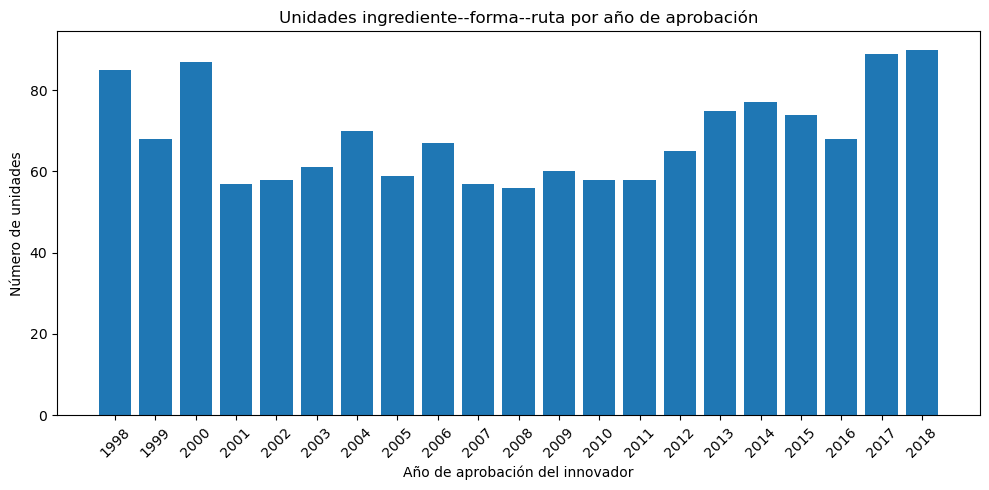

Figura guardada en: /home/violeta/Escritorio/Patentes/figures/units_by_approval_year.png


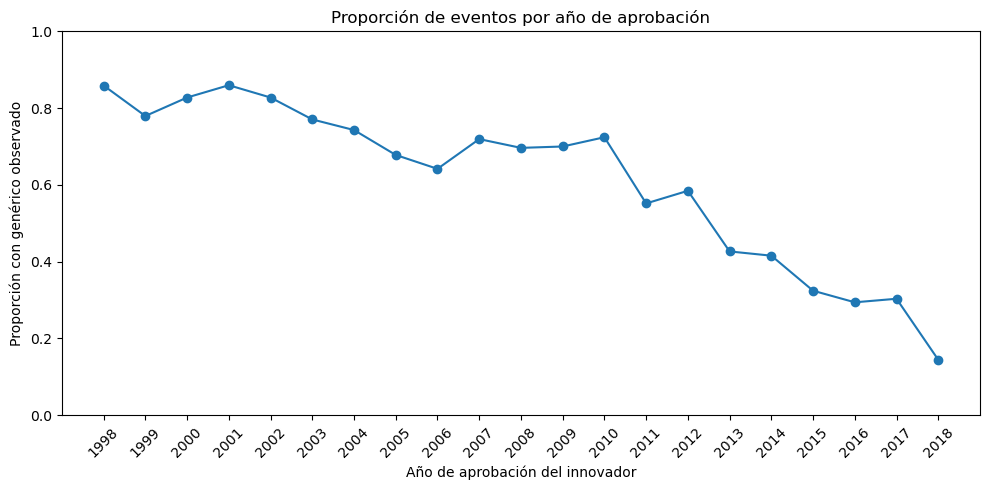

Figura guardada en: /home/violeta/Escritorio/Patentes/figures/event_rate_by_approval_year.png


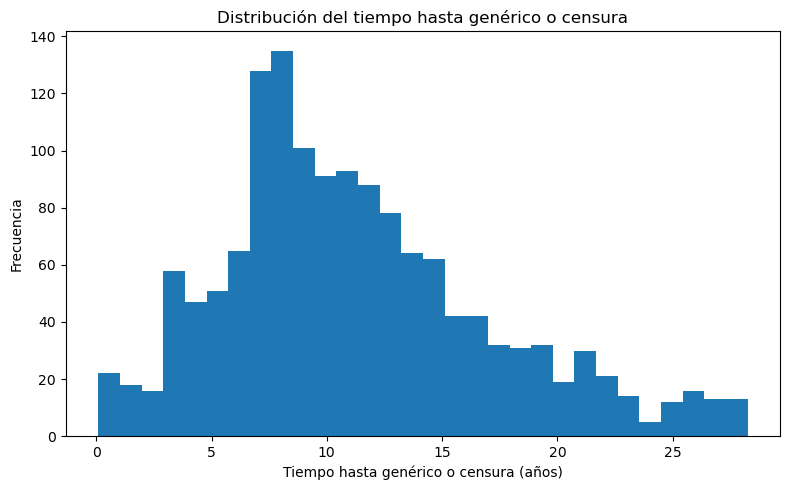

Figura guardada en: /home/violeta/Escritorio/Patentes/figures/time_to_generic_or_censoring_hist.png


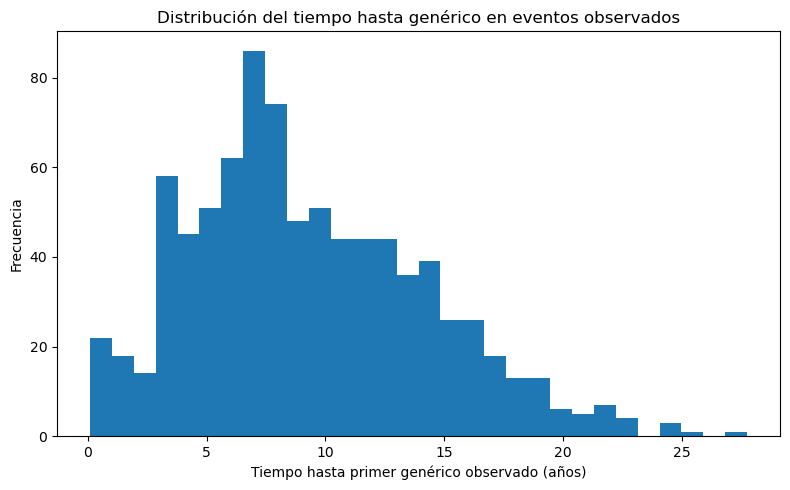

Figura guardada en: /home/violeta/Escritorio/Patentes/figures/time_to_generic_events_only_hist.png


In [19]:
import matplotlib.pyplot as plt


FIGURES_DIR.mkdir(exist_ok=True) #hazlo si no existe 

# ------------------------------------------------------------
# Figura 1: número de unidades por año de aprobación
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5)) #10x5 pulgadas
ax.bar(year_summary["approval_year"], year_summary["n_units"]) #  X = año, eje Y = volumen
ax.set_xlabel("Año de aprobación del innovador") 
ax.set_ylabel("Número de unidades") 
ax.set_title("Unidades ingrediente--forma--ruta por año de aprobación") 
ax.set_xticks(year_summary["approval_year"]) # Fuerza a que el eje X muestre absolutamente todos los años sin saltarse
ax.tick_params(axis="x", rotation=45) # Gira las etiquetas de los años 45 grados para que no se encimen
plt.tight_layout() # Ajusta automáticamente los márgenes para evitar que los textos queden recortados al guardar

fig_path = FIGURES_DIR / "units_by_approval_year.png" # Define la ruta exacta de salida para la imagen
plt.savefig(fig_path, dpi=200, bbox_inches="tight") # Guarda la imagen en alta resolución (200 dpi)
plt.show() 
print(f"Figura guardada en: {fig_path}")

# ------------------------------------------------------------
# Figura 2: proporción de eventos por año de aprobación
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5)) 
ax.plot(year_summary["approval_year"], year_summary["event_rate"], marker="o") # Traza una línea temporal, marcando cada dato con un punto ("o")
ax.set_xlabel("Año de aprobación del innovador")
ax.set_ylabel("Proporción con genérico observado") 
ax.set_title("Proporción de eventos por año de aprobación") 
ax.set_ylim(0, 1) # representando 0% a 100%
ax.set_xticks(year_summary["approval_year"]) 
ax.tick_params(axis="x", rotation=45) 
plt.tight_layout() 

fig_path = FIGURES_DIR / "event_rate_by_approval_year.png" 
plt.savefig(fig_path, dpi=200, bbox_inches="tight") 
plt.show()
print(f"Figura guardada en: {fig_path}") 

# ------------------------------------------------------------
# Figura 3: tiempo hasta genérico o censura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(survival_analysis_v1["time_to_generic_years"], bins=30) #histograma, dividiendo el rango total de años en 30bins
ax.set_xlabel("Tiempo hasta genérico o censura (años)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del tiempo hasta genérico o censura")
plt.tight_layout() 

fig_path = FIGURES_DIR / "time_to_generic_or_censoring_hist.png" 
plt.savefig(fig_path, dpi=200, bbox_inches="tight") 
plt.show() 
print(f"Figura guardada en: {fig_path}") 

# ------------------------------------------------------------
# Figura 4: tiempo hasta genérico en eventos observados
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
events_only = survival_analysis_v1.loc[ 
    survival_analysis_v1["event"].eq(1), #exige que solo pasen los medicamentos que ya perdieron exclusividad
    "time_to_generic_years"] #y extrayendo únicamente su columna de tiempo
ax.hist(events_only, bins=30)
ax.set_xlabel("Tiempo hasta primer genérico observado (años)")
ax.set_ylabel("Frecuencia") 
ax.set_title("Distribución del tiempo hasta genérico en eventos observados")
plt.tight_layout() 

fig_path = FIGURES_DIR / "time_to_generic_events_only_hist.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight") 
plt.show() 
print(f"Figura guardada en: {fig_path}") 

La figura de unidades por año de aprobación muestra que la cohorte tiene observaciones distribuidas en todo el periodo 1998--2018. Aunque hay variación anual, no se observa un año completamente vacío, por lo que la ventana temporal seleccionada es adecuada para una primera exploración.

La figura de proporción de eventos por año de aprobación muestra una disminución clara en los años más recientes. Este patrón es esperable: los productos aprobados en 1998--2004 han tenido muchos más años de seguimiento hasta la fecha de corte de 2026, mientras que los aprobados en 2015--2018 han tenido menos tiempo para observar la entrada de genéricos. Por esta razón, no conviene comparar directamente proporciones crudas entre años sin considerar la censura.

Los histogramas del tiempo hasta genérico muestran una distribución amplia y asimétrica. Entre las unidades con evento observado, la mayor concentración ocurre aproximadamente entre 5 y 12 años, aunque existen eventos tempranos y eventos tardíos. Esto es compatible con la lógica regulatoria del problema, donde los tiempos hasta entrada genérica pueden depender de exclusividades, patentes, formulación, mercado y estrategias regulatorias.

El histograma del tiempo hasta genérico o censura incluye tanto eventos como observaciones censuradas, por lo que muestra tiempos más largos asociados a productos que no tuvieron genérico observado hasta la fecha de corte. Esto refuerza la necesidad de usar métodos de supervivencia, como Kaplan--Meier, en lugar de analizar solo promedios o histogramas.

En conjunto, estas visualizaciones indican que el dataset piloto es funcional y que el siguiente paso natural es estimar la curva Kaplan--Meier global.

## Estimación no paramétrica: Curva Kaplan-Meier global

Después de la exploración descriptiva, ajustaremos la primera curva Kaplan-Meier global, esta técnica (también conocida como estimador de producto límite) es el estándar estadístico para calcular empíricamente la función de supervivencia sin asumir una distribución subyacente de los datos.

Matemáticamente, la función de supervivencia se define como la probabilidad de que la exclusividad de un innovador "sobreviva" más allá de un tiempo $t$:

$$S(t)=P(T>t)$$

Donde $T$ representa el tiempo exacto transcurrido desde la fecha de aprobación del innovador hasta la entrada del primer genérico terapéuticamente equivalente. 

Para calcular esta probabilidad con los datos empíricos, el estimador de Kaplan-Meier utiliza la siguiente productoria:

$$\hat{S}(t)=\prod_{t_i\le t}\left(1-\frac{d_i}{n_i}\right)$$

* $t_i$: Los distintos tiempos discretos en los que ocurre al menos un evento (la entrada de un genérico).
* $d_i$: El número de medicamentos innovadores que pierden exclusividad exactamente en el tiempo $t_i$.
* $n_i$: La población "en riesgo" justo antes de $t_i$; es decir, el número de medicamentos que todavía mantienen su monopolio y no han sido censurados.


La principal ventaja analítica de este método es que nos permite incorporar matemáticamente las observaciones censuradas. Los productos innovadores que aún no tienen genérico observado hasta la fecha de corte de nuestra base de datos no se descartan; en su lugar, permanecen en el denominador ($n_i$) aportando información estadística sobre la "resistencia" del mercado hasta el momento exacto de su censura.


Gráficamente, cada escalón hacia abajo representa la ruptura de una exclusividad. A partir de esta curva, podremos leer directamente métricas críticas de riesgo, como la probabilidad exacta de que un medicamento siga sin competencia a los 10 años, o el tiempo mediano de supervivencia (el punto donde $S(t)=0.5$, indicando que el 50% de la cohorte ya enfrenta competencia).


In [20]:
pip install lifelines

Note: you may need to restart the kernel to use updated packages.


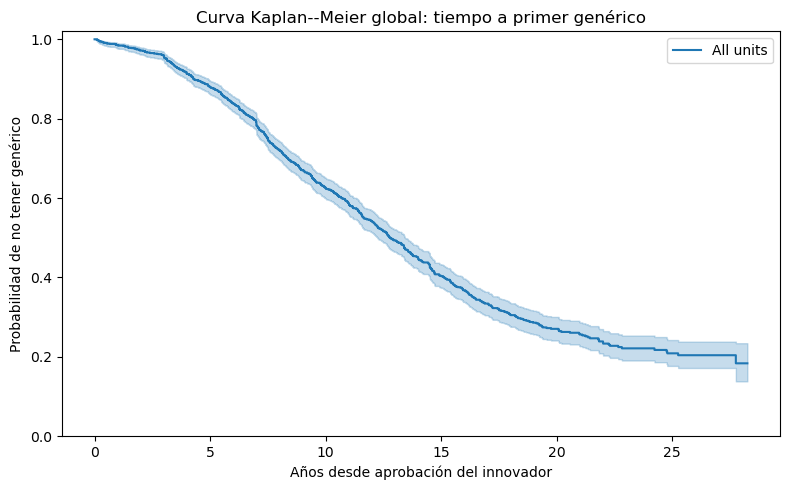

Figura guardada en: /home/violeta/Escritorio/Patentes/figures/km_global_time_to_generic.png

Supervivencia estimada en tiempos seleccionados:
   time_years  survival_probability  probability_generic_by_t
0           5              0.879083                  0.120917
1          10              0.626227                  0.373773
2          15              0.404237                  0.595763
3          20              0.270477                  0.729523

Mediana Kaplan--Meier del tiempo a genérico:
12.791238877481177


In [21]:
try:
    from lifelines import KaplanMeierFitter # Importa la clase principal para calcular la supervivencia no paramétrica
except ImportError as e: # Manejo de error por si no detecta el paquete en tu entorno
    raise ImportError(
        "La librería 'lifelines' no está instalada. "
        "Instálala con: pip install lifelines"
    ) from e # Detiene la ejecución y te indica cómo instalarla

# Datos para Kaplan--Meier
T = survival_analysis_v1["time_to_generic_years"] # Variable T (Time): Extrae el vector de tiempos (años)
E = survival_analysis_v1["event"] # Variable E (Event): Extrae el vector booleano (1=genérico, 0=censura)

kmf = KaplanMeierFitter() # Instancia el modelo matemático
kmf.fit( # Ajusta la curva a la cohorte
    durations=T, # Ingresa los tiempos de seguimiento
    event_observed=E, # Ingresa el estatus de los eventos
    label="All units") 

# Graficar curva KM
fig, ax = plt.subplots(figsize=(8, 5)) 
kmf.plot_survival_function(ax=ax, ci_show=True) # Traza la curva escalonada incluyendo la sombra del intervalo de confianza del 95%
ax.set_xlabel("Años desde aprobación del innovador")
ax.set_ylabel("Probabilidad de no tener genérico") 
ax.set_title("Curva Kaplan--Meier global: tiempo a primer genérico") 
ax.set_ylim(0, 1.02) # Fija el límite vertical
plt.tight_layout() 

fig_path = FIGURES_DIR / "km_global_time_to_generic.png" # Ruta de salida del archivo
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show() 
print(f"Figura guardada en: {fig_path}") 

# Supervivencia estimada en tiempos específicos
times_to_report = [5, 10, 15, 20] 
km_summary = pd.DataFrame({ # Crea un DataFrame para presentar los resultados de forma ordenada
    "time_years": times_to_report, # Primera columna con los años objetivo
    "survival_probability": [ # Segunda columna 
        float(kmf.survival_function_at_times(t).iloc[0]) # Extrae y convierte el valor matemático de S(t) para cada año
        for t in times_to_report # Itera sobre 5, 10, 15 y 20
    ]})
km_summary["probability_generic_by_t"] = 1 - km_summary["survival_probability"] # Calcula el riesgo complementario: probabilidad de ya enfrentar competencia

print("\nSupervivencia estimada en tiempos seleccionados:") 
print(km_summary) 

print("\nMediana Kaplan--Meier del tiempo a genérico:") 
print(kmf.median_survival_time_) # Devuelve el tiempo exacto en el que S(t) cruza la marca probabilística de 0.50

La curva Kaplan--Meier global se estimó correctamente para la base survival_analysis_v1.

En esta figura, la función de supervivencia (S(t)) representa la probabilidad estimada de que una unidad ingrediente--forma--ruta todavía no tenga un genérico comparable después de (t) años desde la aprobación del innovador candidato.

Los resultados principales fueron:

A los 5 años, la probabilidad estimada de no tener genérico es aproximadamente 0.879. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 12.1%.
A los 10 años, la probabilidad estimada de no tener genérico es aproximadamente 0.626. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 37.4%.
A los 15 años, la probabilidad estimada de no tener genérico es aproximadamente 0.404. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 59.6%.
A los 20 años, la probabilidad estimada de no tener genérico es aproximadamente 0.270. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 73.0%.
La mediana Kaplan--Meier del tiempo a genérico fue de aproximadamente 12.79 años. Esto significa que, bajo esta definición preliminar de cohorte y emparejamiento, se estima que el 50% de las unidades tendría un genérico comparable alrededor de 12.8 años después de la aprobación inicial del innovador.

La curva muestra una caída progresiva, especialmente entre aproximadamente 7 y 16 años, lo cual sugiere que una parte importante de la entrada genérica ocurre después de los primeros años de protección regulatoria y comercial.

Es importante recordar que esta es una estimación preliminar. La interpretación final dependerá de refinar la definición de innovador, distinguir productos realmente NME de reformulaciones o nuevas presentaciones, e incorporar variables de patentes y exclusividades.

Esta cola larga que podemos obsrvar hacia la derecha suele estar dominada por formulacionesque dificultan los estudios de bioequivalencia, o por mercados de nicho donde el incentivo económico para desarrollar genéricos es insuficiente. Finalmente, desde el punto de vista estadístico, es crucial notar el ensanchamiento progresivo de las bandas de confianza (la zona sombreada) hacia el final del periodo de observación; este es un efecto directo de la censura por la derecha, ya que la reducción de la población "en riesgo" incrementa de forma natural la incertidumbre en las estimaciones a largo plazo.